In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Introduction

You should process some texts using [NLTK](https://www.nltk.org/) or [spaCy](https://spacy.io/) libraries (ideally both). In particular, you should do the following:
- Load the `harry_potter` book. You can find this text corpus in the datasets folder.
- Segment the text of the book into sentences. How many sentences does this book have?
- Compute the frequency of each token in the book. What are the most frequent tokens?
- Choose a sentence from the book. Analyze this chosen sentence by
    - Calculating all [n-grams](https://en.wikipedia.org/wiki/N-gram).
    - Finding [POS tags](https://en.wikipedia.org/wiki/Part-of-speech_tagging) of tokens.
    - [Stemming](https://en.wikipedia.org/wiki/Stemming) and [lemmatizing](https://en.wikipedia.org/wiki/Lemmatisation) tokens.
- Check the documentation to identify the most important hyperparameters, attributes, and methods. Use them in practice.

In [6]:
!pip install nltk

In [7]:
!pip install textacy

Importing Necessary Libraries

In [8]:
import nltk
import spacy
import textacy
from nltk.corpus import stopwords
import re #regex libary
from nltk.tokenize import RegexpTokenizer
from nltk.tokenize import WordPunctTokenizer
import matplotlib.pyplot as plt

In [9]:
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Load **Data**

In [11]:
f = open("/content/drive/MyDrive/Datasets/harry_potter.txt")    # read txt file in python
text = f.read()
print(text[:1000])

CHAPTER ONE THE BOY WHO LIVED 

Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you'd expect to be involved in anything strange or mysterious, because they just didn't hold with such nonsense. 

Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache. Mrs. Dursley was thin and blonde and had nearly twice the usual amount of neck, which came in very useful as she spent so much of her time craning over garden fences, spying on the neighbors. The Dursleys had a small son called Dudley and in their opinion there was no finer boy anywhere. 

The Dursleys had everything they wanted, but they also had a secret, and their greatest fear was that somebody would discover it. They didn't think they could bear it if anyone found out about the Potters. Mrs. Potter was Mrs. Dursley's sister, b

Sentence Segmentation

In [12]:
nltk_sentences = nltk.sent_tokenize(text)   #sentence segmentation using nltk
len(nltk_sentences)

6394

In [13]:
for i in range(0,5):   #first five sentences using nltk
    print("this is the sentence {}: {}".format(i+1, str(nltk_sentences[i])))

this is the sentence 1: CHAPTER ONE THE BOY WHO LIVED 

Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.
this is the sentence 2: They were the last people you'd expect to be involved in anything strange or mysterious, because they just didn't hold with such nonsense.
this is the sentence 3: Mr. Dursley was the director of a firm called Grunnings, which made drills.
this is the sentence 4: He was a big, beefy man with hardly any neck, although he did have a very large mustache.
this is the sentence 5: Mrs. Dursley was thin and blonde and had nearly twice the usual amount of neck, which came in very useful as she spent so much of her time craning over garden fences, spying on the neighbors.


In [14]:
doc = nlp(text)
spacy_sentences = list(doc.sents)
len(spacy_sentences)

6232

In [15]:
for i in range(0,5):   ##first five sentences using spacy
    print("this is the sentence {}: {}".format(i+1, str(spacy_sentences[i])))

this is the sentence 1: CHAPTER ONE THE BOY WHO LIVED 

Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.
this is the sentence 2: They were the last people you'd expect to be involved in anything strange or mysterious, because they just didn't hold with such nonsense. 


this is the sentence 3: Mr. Dursley was the director of a firm called Grunnings, which made drills.
this is the sentence 4: He was a big, beefy man with hardly any neck, although he did have a very large mustache.
this is the sentence 5: Mrs. Dursley was thin and blonde and had nearly twice the usual amount of neck, which came in very useful as she spent so much of her time craning over garden fences, spying on the neighbors.


Word Tokenization



here we compute the frequency of each token with nltk in the book & most frequent tokens
**( without pre-processing and removing punctuations!)**

In [16]:
tokens = {}
for s in nltk_sentences:
    sentence_tokens = nltk.tokenize.word_tokenize(s)
    for t in sentence_tokens:
        if t not in tokens:
            tokens[t] = 0
        tokens[t] += 1
frequent_tokens = sorted(tokens, key=tokens.get, reverse=True)[:20]
for t in frequent_tokens:
    print(t, "\t\t\t\t", tokens[t])

, 				 5658
. 				 5119
the 				 3310
'' 				 2441
`` 				 2307
to 				 1845
and 				 1804
a 				 1578
Harry 				 1323
was 				 1253
of 				 1242
he 				 1208
's 				 997
in 				 933
I 				 919
it 				 897
his 				 896
you 				 837
n't 				 826
said 				 793


here we compute the frequency of each token with  nltk in the book & most frequent tokens **( with pre-processing and removing punctuations)** which one is more informative?

In [20]:
import string # Import the string module
tokens = {}
for s in nltk_sentences:
    sentence_tokens = WordPunctTokenizer().tokenize(s)  #use another tokenizer
    for t in sentence_tokens:
        if t not in tokens:
            tokens[t] = 0
        tokens[t] += 1
stop_words = set(stopwords.words('english'))

# Define a set of punctuation tokens to exclude
# string.punctuation covers single-character punctuation like '.', ',', '?', '!', etc.
punctuation_tokens_to_exclude = set(string.punctuation)
punctuation_tokens_to_exclude.update(["''", "``", "--"]) # Add multi-character punctuation tokens

# Filter out punctuation tokens first, then stopwords
cleaned_tokens_stage1 = (token for token in tokens.keys() if token not in punctuation_tokens_to_exclude)
filtered_tokens = [word for word in cleaned_tokens_stage1 if word.lower() not in stop_words]

# Sort by frequency from the original 'tokens' dictionary
frequent_tokens = sorted(filtered_tokens, key=lambda x: tokens.get(x, 0), reverse=True)[:20]
for t in frequent_tokens:
    print(t, "\t\t\t\t", tokens[t])

Harry 				 1325
said 				 793
," 				 687
." 				 636
?" 				 502
Ron 				 429
Hagrid 				 370
!" 				 308
Hermione 				 270
back 				 258
one 				 232
could 				 190
like 				 189
got 				 186
know 				 186
get 				 183
Professor 				 181
Snape 				 172
looked 				 169
see 				 162


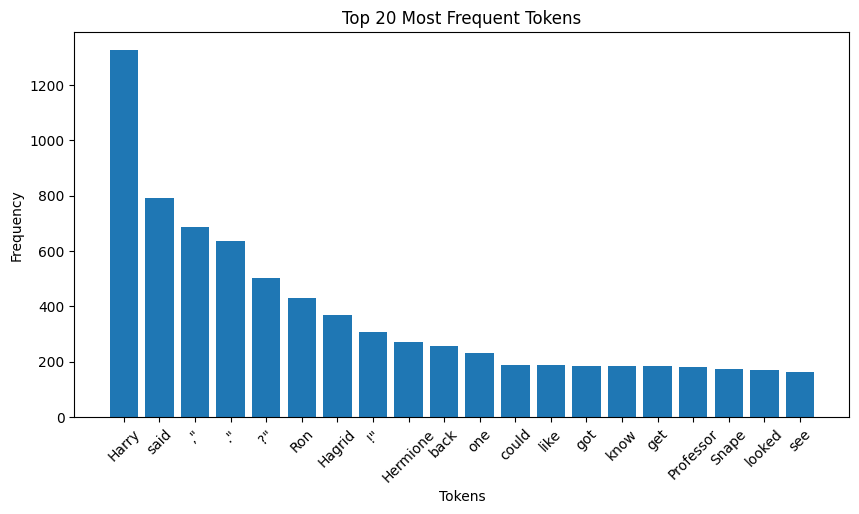

In [21]:
import matplotlib.pyplot as plt

words = frequent_tokens
freqs = [tokens[t] for t in frequent_tokens]

plt.figure(figsize=(10, 5))
plt.bar(words, freqs)

plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Tokens")
plt.xlabel("Tokens")
plt.ylabel("Frequency")

plt.show()

In [22]:
tokens = {}
for t in doc:
    if t.text not in tokens:
        tokens[t.text] = 0
    tokens[t.text] += 1

frequent_tokens = sorted(tokens, key=tokens.get, reverse=True)[:20]
for t in frequent_tokens:
    print(t.replace("\n", "<NEWLINE>"), "\t\t\t\t", tokens[t])

, 				 5658
. 				 5125
" 				 4747
the 				 3312
<NEWLINE><NEWLINE> 				 3014
to 				 1851
and 				 1807
a 				 1581
Harry 				 1324
was 				 1253
of 				 1250
he 				 1208
's 				 998
in 				 935
I 				 922
it 				 898
his 				 896
you 				 838
n't 				 821
said 				 793


## N-Gram Computation

In [23]:
nltk_sentence = nltk_sentences[2]
sentence_tokens = nltk.tokenize.word_tokenize(nltk_sentence)
ngrams = list(nltk.ngrams(sentence_tokens, 2))
print(nltk_sentence)
ngrams

Mr. Dursley was the director of a firm called Grunnings, which made drills.


[('Mr.', 'Dursley'),
 ('Dursley', 'was'),
 ('was', 'the'),
 ('the', 'director'),
 ('director', 'of'),
 ('of', 'a'),
 ('a', 'firm'),
 ('firm', 'called'),
 ('called', 'Grunnings'),
 ('Grunnings', ','),
 (',', 'which'),
 ('which', 'made'),
 ('made', 'drills'),
 ('drills', '.')]

POS Tagging

In [25]:
print(nltk_sentence)
pos_tags = nltk.pos_tag(sentence_tokens)
for t, tag in pos_tags:
    print(t, "\t\t", tag)

Mr. Dursley was the director of a firm called Grunnings, which made drills.


LookupError: 
**********************************************************************
  Resource [93maveraged_perceptron_tagger_eng[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('averaged_perceptron_tagger_eng')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtaggers/averaged_perceptron_tagger_eng/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [26]:
spacy_sentence = spacy_sentences[2]
sentence_doc = nlp(spacy_sentence.text)
ngrams = list(textacy.extract.basics.ngrams(sentence_doc, 2, filter_stops=False))
print(spacy_sentence)
ngrams

Mr. Dursley was the director of a firm called Grunnings, which made drills.


[Mr. Dursley,
 Dursley was,
 was the,
 the director,
 director of,
 of a,
 a firm,
 firm called,
 called Grunnings,
 which made,
 made drills]

In [27]:
print(spacy_sentence)
for t in sentence_doc:
    print(t.text, "\t\t", t.pos_)

Mr. Dursley was the director of a firm called Grunnings, which made drills.
Mr. 		 PROPN
Dursley 		 PROPN
was 		 AUX
the 		 DET
director 		 NOUN
of 		 ADP
a 		 DET
firm 		 NOUN
called 		 VERB
Grunnings 		 PROPN
, 		 PUNCT
which 		 PRON
made 		 VERB
drills 		 NOUN
. 		 PUNCT


POS Tagging

In [28]:
print(nltk_sentence)
pos_tags = nltk.pos_tag(sentence_tokens)
for t, tag in pos_tags:
    print(t, "\t\t", tag)

Mr. Dursley was the director of a firm called Grunnings, which made drills.


LookupError: 
**********************************************************************
  Resource [93maveraged_perceptron_tagger_eng[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('averaged_perceptron_tagger_eng')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtaggers/averaged_perceptron_tagger_eng/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


Stemming

In [29]:
print(nltk_sentence)
porter = nltk.stem.PorterStemmer()
for t in sentence_tokens:
    print(t, "\t\t", porter.stem(t))

Mr. Dursley was the director of a firm called Grunnings, which made drills.
Mr. 		 mr.
Dursley 		 dursley
was 		 wa
the 		 the
director 		 director
of 		 of
a 		 a
firm 		 firm
called 		 call
Grunnings 		 grun
, 		 ,
which 		 which
made 		 made
drills 		 drill
. 		 .


Lemmatization

In [30]:
print(nltk_sentence)
lemmatizer = nltk.stem.WordNetLemmatizer()
for t in sentence_tokens:
    print(t, "\t\t", lemmatizer.lemmatize(t))

Mr. Dursley was the director of a firm called Grunnings, which made drills.
Mr. 		 Mr.
Dursley 		 Dursley
was 		 wa
the 		 the
director 		 director
of 		 of
a 		 a
firm 		 firm
called 		 called
Grunnings 		 Grunnings
, 		 ,
which 		 which
made 		 made
drills 		 drill
. 		 .


In [31]:
print(spacy_sentence)
for t in sentence_doc:
    print(t.text, "\t\t", t.lemma_)

Mr. Dursley was the director of a firm called Grunnings, which made drills.
Mr. 		 Mr.
Dursley 		 Dursley
was 		 be
the 		 the
director 		 director
of 		 of
a 		 a
firm 		 firm
called 		 call
Grunnings 		 Grunnings
, 		 ,
which 		 which
made 		 make
drills 		 drill
. 		 .
